# Chapter 5a -- Impact investing market & instruments

Opens Chapter 5 (Impact Investing) with the market and instrument layer:
how large the private impact investing market is and how it is raising and
deploying capital (PitchBook data), the ImpactAssets 50 fund universe by
asset class, blended-finance tranche structures (a first-loss/junior layer
absorbing defaults to protect a senior layer, simulated both deterministically
and under a one-factor Gaussian-copula default model), the blue-economy fund
segment, a simple illustration of counterfactual impact measurement, and
SDG-alignment scoring at both the country and fund level.

Chapter 5's remaining sections are a large embedded case study on
biodiversity/natural capital as an impact-investing theme, split across
`05b`-`05d`.

A handful of sections read real market/ranking data shipped in this repo's
`Data/` folder (PitchBook private-markets data, the ImpactAssets 50 fund
list, and UN SDG/spillover country indices) via `pandas.read_excel`. The
rest reproduce illustrative figures and Monte Carlo simulations from
hardcoded reference values -- including section 1.4, which loads the
PitchBook file but does not actually use it, instead hardcoding its own,
larger capital-raised series from a different, broader-market source than
the PitchBook cut used in section 1.2/1.3.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"
rng = np.random.default_rng(123)


## 1. The private impact investing market

PitchBook's private impact-fund universe: assets under management, fund
count, and capital raised, read from the `AUM` sheet of
`chap5_pitchbook_market.xlsx`.

In [2]:

aum = pd.read_excel(f"{DATA_DIR}/chap5_pitchbook_market.xlsx", sheet_name="AUM")
aum.head()


,Year,Dry_powder,Remaining_value,Fund_count,Capital_raised
0,2007,24.771564,17.551359,67,9.634614
1,2008,52.722129,30.699555,74,44.453064
2,2009,55.366463,46.075736,71,21.398025
3,2010,61.785142,64.334818,78,23.748454
4,2011,64.979194,82.184819,84,24.769463


### 1.1 Assets under management: dry powder vs. remaining value

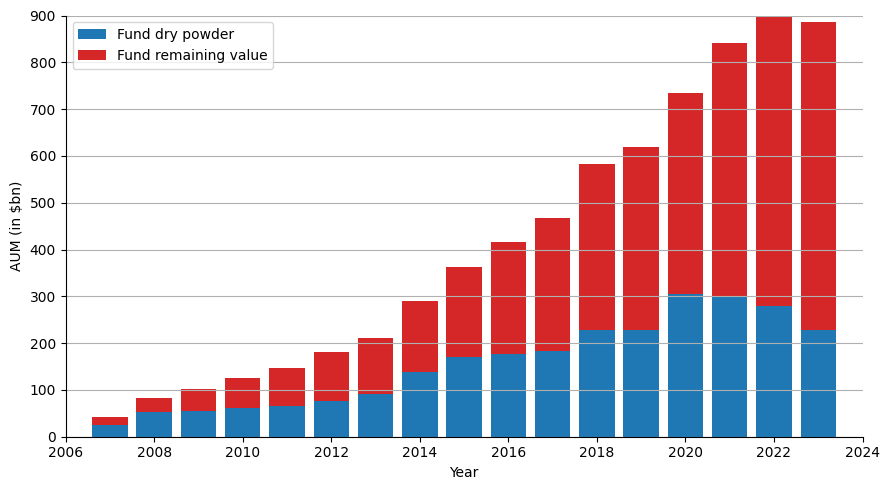

In [3]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(aum["Year"], aum["Dry_powder"], color="tab:blue", label="Fund dry powder")
ax.bar(aum["Year"], aum["Remaining_value"], bottom=aum["Dry_powder"],
       color="tab:red", label="Fund remaining value")
ax.set_xlabel("Year")
ax.set_ylabel("AUM (in $bn)")
ax.set_xlim(2006, 2024)
ax.set_ylim(0, 900)
ax.legend()
ax.grid(axis="y")
plt.tight_layout()


### 1.2 Fund count and capital raised, annual

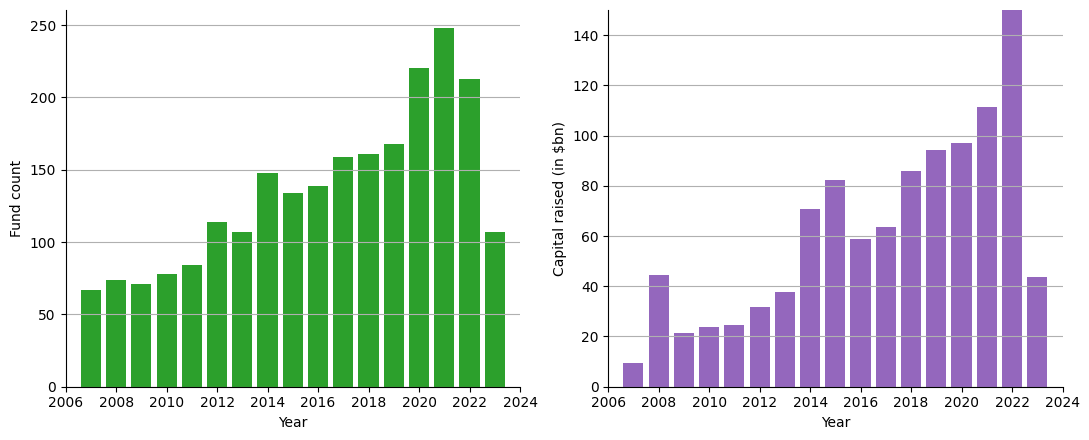

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(aum["Year"], aum["Fund_count"], color="tab:green")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Fund count")
axes[0].grid(axis="y")

axes[1].bar(aum["Year"], aum["Capital_raised"], color="tab:purple")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Capital raised (in $bn)")
axes[1].set_ylim(0, 150)
axes[1].grid(axis="y")

for ax in axes:
    ax.set_xlim(2006, 2024)

plt.tight_layout()


### 1.3 Fund count and capital raised, cumulative

Same data, running totals.

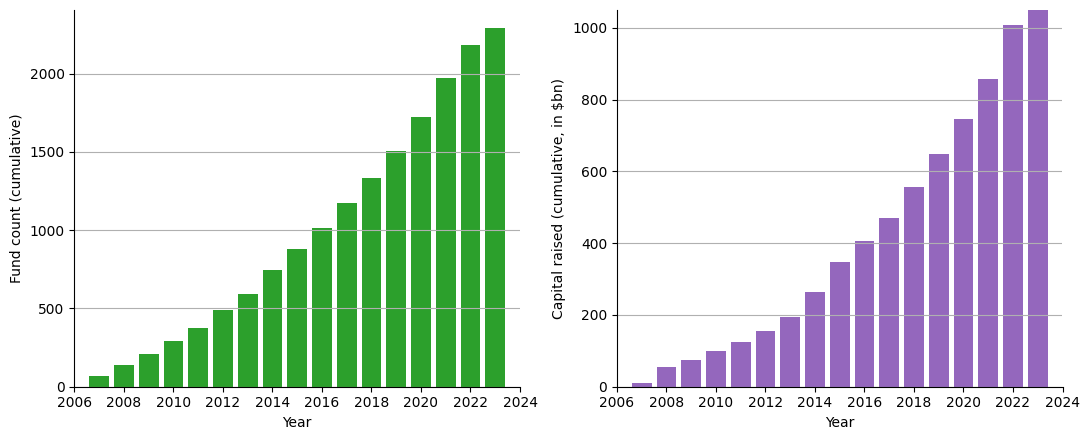

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(aum["Year"], aum["Fund_count"].cumsum(), color="tab:green")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Fund count (cumulative)")
axes[0].grid(axis="y")

axes[1].bar(aum["Year"], aum["Capital_raised"].cumsum(), color="tab:purple")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Capital raised (cumulative, in $bn)")
axes[1].set_ylim(0, 1050)
axes[1].grid(axis="y")

for ax in axes:
    ax.set_xlim(2006, 2024)

plt.tight_layout()


### 1.4 A broader-market cumulative capital-raised series

This figure loads the PitchBook `AUM` sheet but does not actually use it --
it hardcodes its own year/capital-raised series instead. Reproduced as-is
(a different, larger-scale source than PitchBook's own capital-raised
column above, consistent with citing multiple market-sizing surveys across
the chapter).

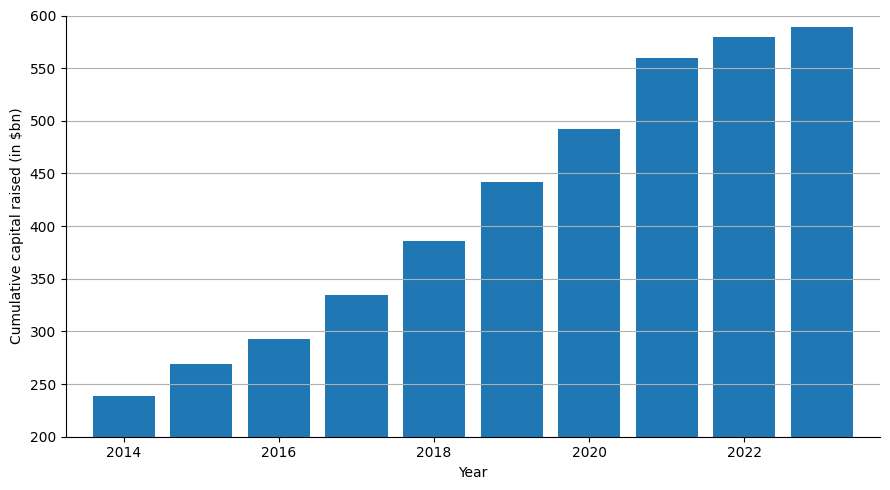

In [6]:

aum4_year = np.arange(2014, 2024)
aum4_capital_raised = np.array([239, 269, 293, 335, 386, 442, 492, 560, 580, 589])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(aum4_year, aum4_capital_raised, color="tab:blue")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative capital raised (in $bn)")
ax.set_xlim(2013.25, 2023.75)
ax.set_ylim(200, 600)
ax.grid(axis="y")
plt.tight_layout()


## 2. The ImpactAssets 50: fund universe by asset class

The ImpactAssets 50 is an annually curated list of experienced impact
investing fund managers. The `Table` sheet of `chap5_impactassets50.xlsx`
flags, for each of the 50 funds, which of seven asset classes it invests
through (a fund can span more than one).

In [7]:

ia50 = pd.read_excel(f"{DATA_DIR}/chap5_impactassets50.xlsx", sheet_name="Table")
asset_classes = ["Cash", "Commodities", "Private Debt", "Private Equity",
                  "Public Debt", "Public Equity", "Real Estate"]
ia50[asset_classes] = ia50[asset_classes].fillna(0).astype(int)
ia50[["Fund"] + asset_classes].head(10)


,Fund,Cash,Commodities,Private Debt,Private Equity,Public Debt,Public Equity,Real Estate
0,Absolute Portfolio Management,0,0,0,0,1,0,0
1,Accion,0,0,0,1,0,0,0
2,Acumen Capital Partners LLC,0,0,0,1,0,0,0
3,Bamboo Finance,0,0,1,1,0,0,0
4,"BAML Capital Access Funds Management, LLC",0,0,0,1,0,0,0
5,Beartooth Capital,0,0,0,0,0,0,1
6,BlueOrchard Finance Ltd,0,0,1,1,0,0,0
7,Bridges Fund Management Ltd,0,0,0,1,0,0,0
8,Calvert Impact,0,0,1,0,0,0,0
9,City Light Capital,0,0,0,1,0,0,0


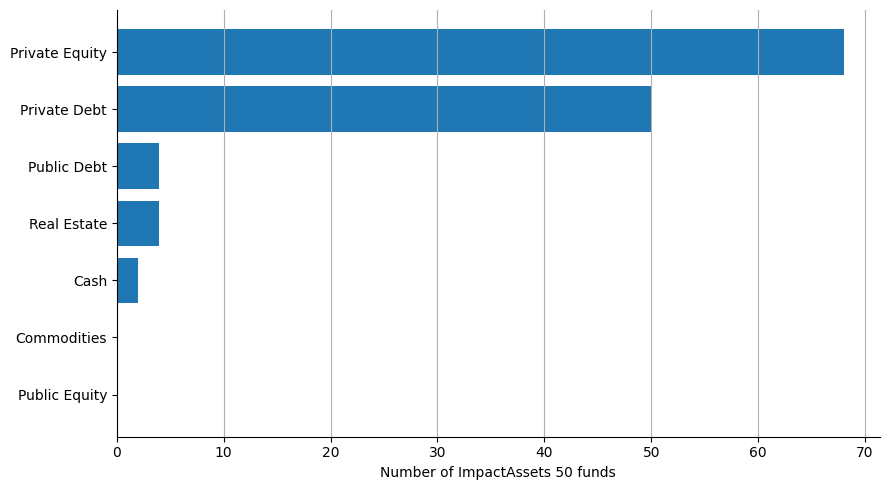

In [8]:

fund_count_by_class = ia50[asset_classes].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fund_count_by_class.index[::-1], fund_count_by_class.values[::-1], color="tab:blue")
ax.set_xlabel("Number of ImpactAssets 50 funds")
ax.grid(axis="x")
plt.tight_layout()


## 3. Blended finance: tranching donor and commercial capital

Blended finance layers a small junior (first-loss) tranche -- typically
funded by donors/DFIs -- underneath a larger senior tranche sized for
commercial investors, so that portfolio defaults are absorbed by the
junior tranche first and the senior tranche's return is protected as long
as losses stay below the junior tranche's size.

### 3.1 The waterfall model

Given a portfolio of `n` equal-notional loans/bonds, a recovery rate, a
default path `nt_default` (cumulative number of defaults by period), and
coupon rates for the junior/senior tranches, the function allocates
cumulative losses `Lt` and cumulative coupon income `Gt` between the two
tranches and returns each tranche's annualized return `Rt_bar` at every
period.

This is a generic cash-flow waterfall primitive, not specific to any one
example below -- reused as-is in both the deterministic scenarios (3.2) and
the Monte Carlo simulation (3.3), a plausible candidate for
`quanttoolbox` if a later chapter's blended-finance content needs it too.

In [9]:

# Two-tranche (junior/senior) cash-flow waterfall for a blended-finance portfolio.
#   N0                 total portfolio notional
#   D_junior           junior (first-loss) tranche size
#   Ni                 notional per underlying loan/bond
#   Ri                 recovery rate on default
#   ci                 coupon rate paid by the underlying loans/bonds
#   coupon_rate_senior minimum coupon rate promised to the senior tranche
#   nt_default         cumulative number of defaults by period (array over time)
#
# Returns a BlendedFinanceResult dataclass of per-period series for the
# portfolio, junior tranche and senior tranche: cumulative losses (lt),
# cumulative coupon income (gt), cumulative return (rt) and annualized
# return (rt_bar), plus the period index (t).
from quanttoolbox.sustainable_finance.impact import blended_finance_simulation


### 3.2 Three deterministic default scenarios

A $500m portfolio of $5m loans with a 20% junior tranche, run through three
hypothetical default paths (mild/severe/moderate) over 10 years.

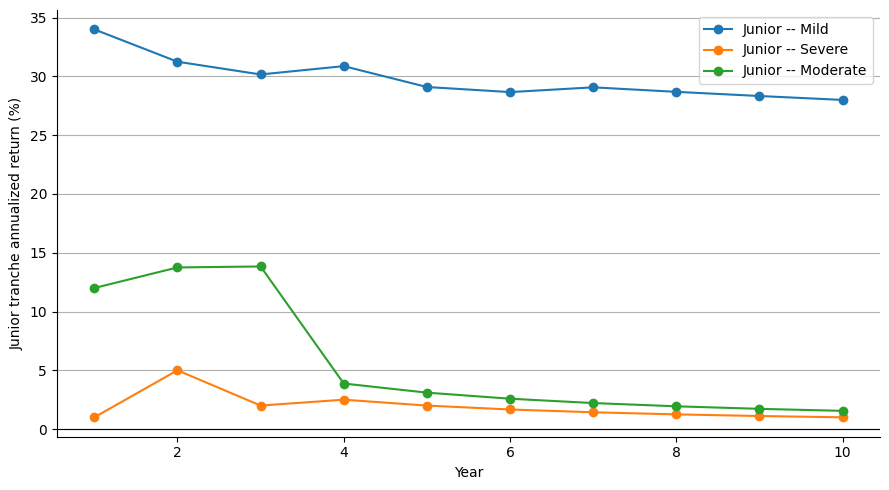

In [10]:

N0 = 500
D_junior = 0.20 * N0
Ni = 5
Ri = 0.0
ci = 0.10
coupon_rate_senior = 0.04

scenarios = {
    "Mild": [0, 1, 2, 2, 4, 5, 5, 6, 7, 8],
    "Severe": [6, 10, 16, 20, 25, 30, 32, 36, 40, 41],
    "Moderate": [4, 7, 10, 20, 24, 27, 29, 30, 33, 34],
}

fig, ax = plt.subplots(figsize=(9, 5))
for name, nt_default in scenarios.items():
    res = blended_finance_simulation(N0, D_junior, Ni, Ri, ci, coupon_rate_senior, nt_default)
    ax.plot(res.t, 100 * res.rt_bar_junior, marker="o", label=f"Junior -- {name}")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Junior tranche annualized return (%)")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()


In [11]:

rows = []
for name, nt_default in scenarios.items():
    res = blended_finance_simulation(N0, D_junior, Ni, Ri, ci, coupon_rate_senior, nt_default)
    rows.append({
        "Scenario": name,
        "Defaults (yr 10)": nt_default[-1],
        "Portfolio return (%)": round(100 * res.rt_bar[-1], 2),
        "Junior return (%)": round(100 * res.rt_bar_junior[-1], 2),
        "Senior return (%)": round(100 * res.rt_bar_senior[-1], 2),
    })
pd.DataFrame(rows)


,Scenario,Defaults (yr 10),Portfolio return (%),Junior return (%),Senior return (%)
0,Mild,8,8.80,28.00,4.00
1,Severe,41,3.34,1.00,3.92
2,Moderate,34,4.42,1.55,5.14


### 3.3 Monte Carlo: tranche return distributions under correlated defaults

Default times are simulated from a one-factor Gaussian copula (systematic
factor $X$, idiosyncratic $\epsilon_i$, asset correlation $\rho$) mapped
through an exponential intensity `lambda`, for two correlation regimes.
Higher default correlation ($\rho = 50\%$) fattens both tails of the junior
tranche's return distribution relative to the independent-default case
($\rho = 0\%$), while leaving the senior tranche comparatively protected.
Kernel density estimation uses `scipy.stats.gaussian_kde`.

In [12]:

N0 = 500
D_junior = 0.20 * N0
Ni = 5
Ri = 0.0
ci = 0.10
coupon_rate_senior = 0.04
maturity = 10
t_grid = np.arange(1, maturity + 1)
lam = 0.03
n = int(N0 / Ni)
nS = 20_000

def simulate_returns(rho, seed):
    g = np.random.default_rng(seed)
    X = g.standard_normal(nS)
    eps = g.standard_normal((nS, n))
    Z = np.sqrt(rho) * X[:, None] + np.sqrt(1 - rho) * eps
    u = norm.cdf(Z)
    tau = -np.log(1 - u) / lam
    nt_default_path = (tau[:, :, None] <= t_grid[None, None, :]).sum(axis=1)

    out = np.zeros((nS, 3))
    for i in range(nS):
        res = blended_finance_simulation(
            N0, D_junior, Ni, Ri, ci, coupon_rate_senior, nt_default_path[i]
        )
        out[i] = [100 * res.rt_bar[-1], 100 * res.rt_bar_junior[-1], 100 * res.rt_bar_senior[-1]]
    return out

result_rho0 = simulate_returns(0.00, seed=123)
result_rho50 = simulate_returns(0.50, seed=456)

pd.DataFrame({
    "Mean return (%), rho=0": result_rho0.mean(axis=0),
    "Mean return (%), rho=50%": result_rho50.mean(axis=0),
}, index=["Portfolio", "Junior", "Senior"]).round(2)


,"Mean return (%), rho=0","Mean return (%), rho=50%"
Portfolio,5.93,5.92
Junior,10.80,16.81
Senior,4.71,3.20


The $\rho=0\%$ junior/senior tranche return distributions come out
multi-modal at the default kernel bandwidth (defaults across 20,000 paths
cluster on a fairly small set of integer counts when there's no common
factor driving them together) -- the bandwidth is widened for those two
curves specifically (`1.75x` for the junior tranche, `1.5x` for the senior
tranche) via `gaussian_kde`'s bandwidth factor.

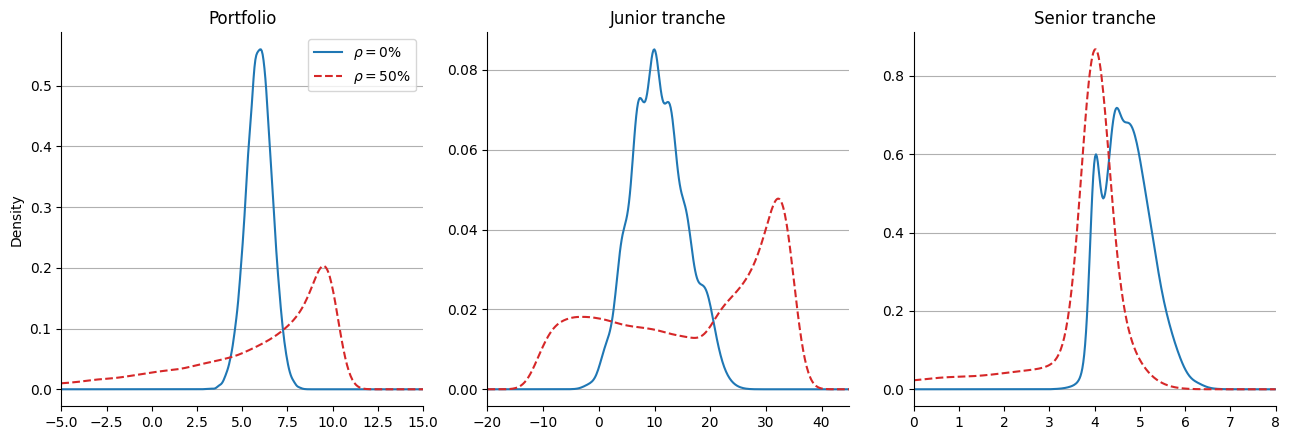

In [13]:

titles = ["Portfolio", "Junior tranche", "Senior tranche"]
xlims = [(-5, 15), (-20, 45), (0, 8)]
rho0_bw_scale = [1.0, 1.75, 1.5]  # widened bandwidth for rho=0 (see note above)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for i, (title, xlim) in enumerate(zip(titles, xlims)):
    x = np.linspace(*xlim, 400)
    kde0 = gaussian_kde(result_rho0[:, i])
    d0 = gaussian_kde(result_rho0[:, i], bw_method=kde0.factor * rho0_bw_scale[i])(x)
    d50 = gaussian_kde(result_rho50[:, i])(x)
    axes[i].plot(x, d0, color="tab:blue", label=r"$\rho=0\%$")
    axes[i].plot(x, d50, "--", color="tab:red", label=r"$\rho=50\%$")
    axes[i].set_title(title)
    axes[i].set_xlim(xlim)
    axes[i].grid(axis="y")
axes[0].legend()
axes[0].set_ylabel("Density")
plt.tight_layout()


### 3.4 Blended finance deal flow

Number of blended-finance deals and total capital raised per year,
2015-2024 (hardcoded reference values).

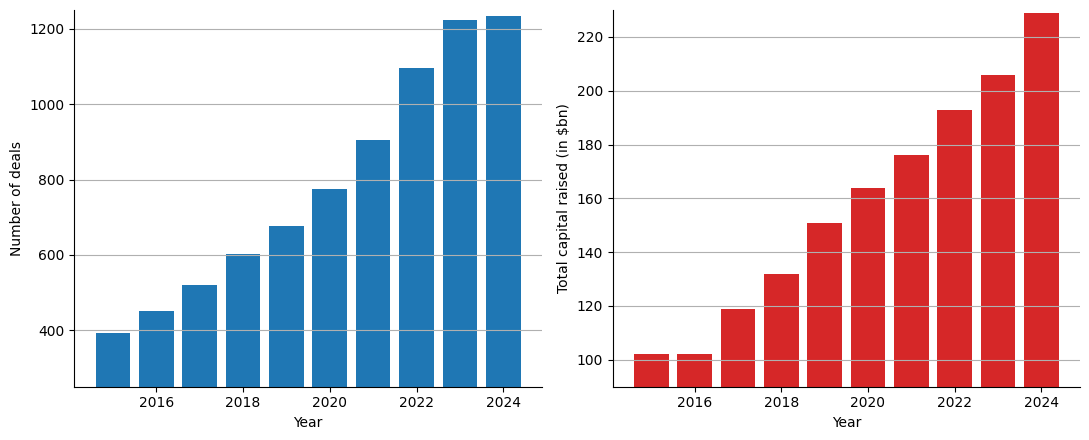

In [14]:

year = np.arange(2015, 2025)
deals = np.array([392, 451, 520, 603, 677, 774, 904, 1097, 1224, 1233])
capital_raised = np.array([102, 102, 119, 132, 151, 164, 176, 193, 206, 229])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(year, deals, color="tab:blue")
axes[0].set_ylabel("Number of deals")
axes[0].set_ylim(250, 1250)

axes[1].bar(year, capital_raised, color="tab:red")
axes[1].set_ylabel("Total capital raised (in $bn)")
axes[1].set_ylim(90, 230)

for ax in axes:
    ax.set_xlabel("Year")
    ax.grid(axis="y")

plt.tight_layout()


## 4. The blue economy fund segment

Number of active blue-economy (ocean/water-related) private funds,
2015-2024 (hardcoded reference values).

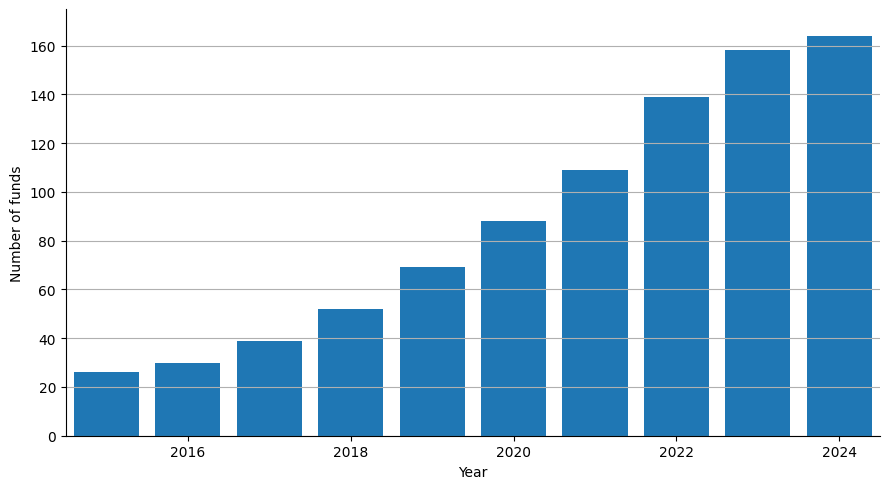

In [15]:

year = np.arange(2015, 2025)
blue_funds = np.array([26, 30, 39, 52, 69, 88, 109, 139, 158, 164])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(year, blue_funds, color="tab:blue")
ax.set_xlabel("Year")
ax.set_ylabel("Number of funds")
ax.set_xlim(2014.5, 2024.5)
ax.set_ylim(0, 175)
ax.grid(axis="y")
plt.tight_layout()


## 5. Illustrating impact measurement

Two small illustrations of how an impact investor's contribution to
outcomes is typically measured.

### 5.1 Blending outcome contributions across five investments

A stylized portfolio of five investments, each with an investor ownership
share `c` and four outcome metrics; the portfolio-level, ownership-weighted
contribution is the ownership-weighted sum across investments.

In [16]:

c = np.array([0.10, 0.05, 0.20, 0.50, 0.12])
impact = np.array([
    [1700, 1300, 300, 0],
    [1500, 650, 100, 0],
    [700, 1150, 75, 0],
    [5000, 0, 150, 5000],
    [3200, 0, 510, 15000],
])
impact_investor = (c[:, None] * impact).sum(axis=0)
pd.DataFrame([impact_investor], columns=["Metric 1", "Metric 2", "Metric 3", "Metric 4"], index=["Weighted contribution"]).round(1)


,Metric 1,Metric 2,Metric 3,Metric 4
Weighted contribution,3269.0,392.5,186.2,4300.0


### 5.2 Counterfactual outcome: treated vs. control

A canonical difference-in-differences illustration: an outcome (employee
count, log scale) for a treated group (impact investment made at $t=0$)
diverging from a matched control group after the investment.

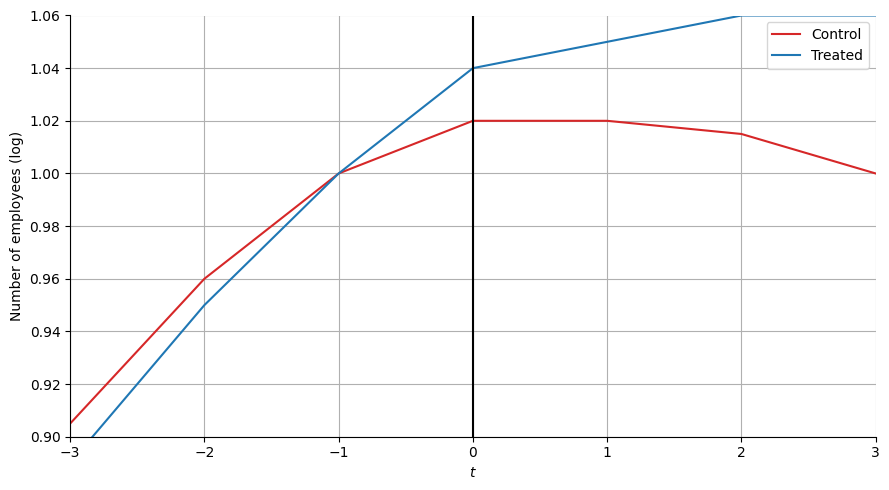

In [17]:

t = np.array([-3, -2, -1, 0, 1, 2, 3])
control = np.array([0.905, 0.96, 1.00, 1.02, 1.02, 1.015, 1.00])
treated = np.array([0.89, 0.95, 1.00, 1.04, 1.05, 1.060, 1.06])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t, control, color="tab:red", label="Control")
ax.plot(t, treated, color="tab:blue", label="Treated")
ax.axvline(0, color="black", linewidth=1.5)
ax.set_xlabel("$t$")
ax.set_ylabel("Number of employees (log)")
ax.set_xlim(-3, 3)
ax.set_ylim(0.90, 1.06)
ax.legend()
ax.grid(True)
plt.tight_layout()


## 6. SDG-alignment scoring

### 6.1 Country SDG index vs. spillover index

Countries doing well on their own SDG index can still generate negative
spillovers (via trade, finance, environment) onto other countries' ability
to achieve the SDGs -- read from the `SDG index` and `Spillover index`
sheets of `chap5_sdg_ranking.xlsx`, joined by country. A quadratic fit
summarizes the (weak, non-monotonic) relationship.

In [18]:

sdg_index = pd.read_excel(f"{DATA_DIR}/chap5_sdg_ranking.xlsx", sheet_name="SDG index")
spillover_index = pd.read_excel(f"{DATA_DIR}/chap5_sdg_ranking.xlsx", sheet_name="Spillover index")

sdg_table = sdg_index.merge(spillover_index, on="Country", suffixes=("_SDG", "_Spillover"))
score_sdg = sdg_table["Score_SDG"]
score_spillover = sdg_table["Score_Spillover"]

corr_table = pd.Series({
    "Pearson": score_sdg.corr(score_spillover, method="pearson"),
    "Kendall": score_sdg.corr(score_spillover, method="kendall"),
    "Spearman": score_sdg.corr(score_spillover, method="spearman"),
}) * 100
corr_table.round(2)


Pearson    -56.21
Kendall    -42.43
Spearman   -61.12
dtype: float64

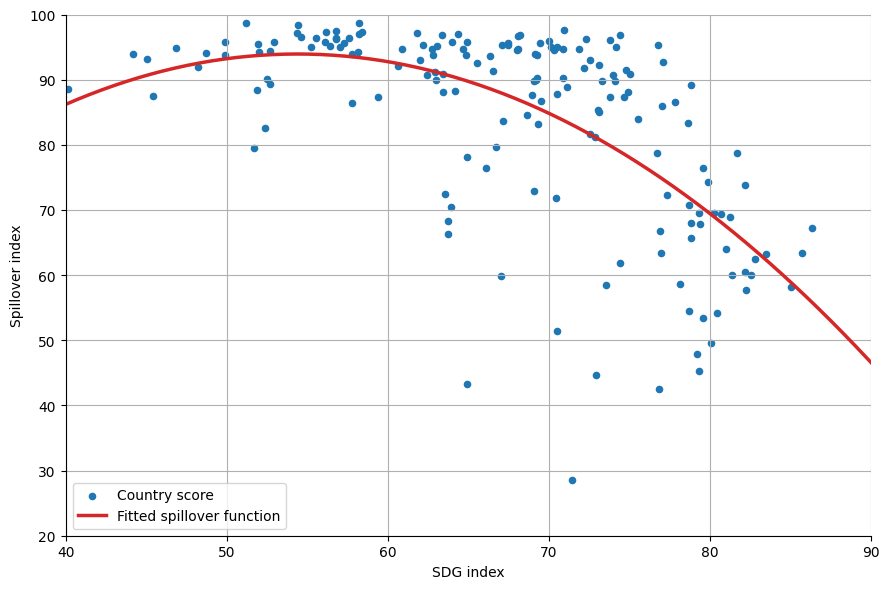

In [19]:

beta = np.polyfit(score_sdg, score_spillover, 2)
x_fit = np.linspace(40, 90, 200)
y_fit = np.polyval(beta, x_fit)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(score_sdg, score_spillover, s=20, color="tab:blue", label="Country score")
ax.plot(x_fit, y_fit, color="tab:red", linewidth=2.5, label="Fitted spillover function")
ax.set_xlabel("SDG index")
ax.set_ylabel("Spillover index")
ax.set_xlim(40, 90)
ax.set_ylim(20, 100)
ax.legend()
ax.grid(True)
plt.tight_layout()


### 6.2 Fund-level SDG scores by goal

Average per-goal SDG alignment score for a sample of SDG-labelled funds
vs. non-SDG funds (data from a Natacha Mosson study, superseding an
earlier, coarser "visual recognition" estimate).

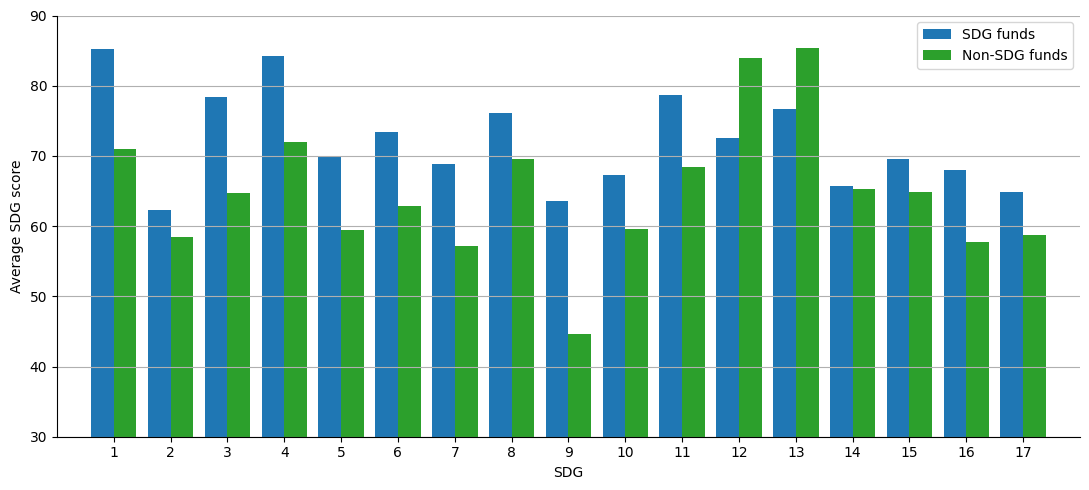

In [20]:

sdg_goals = np.arange(1, 18)
sdg_funds = np.array([
    85.27099408, 62.23552373, 78.35763598, 84.25306463, 69.88766955, 73.36332622,
    68.84338097, 76.07852129, 63.52370039, 67.24430627, 78.73308319, 72.61549291,
    76.61100408, 65.68524146, 69.58908951, 67.99826206, 64.80159682,
])
non_sdg_funds = np.array([
    71.03345121, 58.38365408, 64.66096287, 72.01634102, 59.44982689, 62.8459108,
    57.09724851, 69.55616661, 44.67392308, 59.61720564, 68.37471992, 83.93576122,
    85.31949446, 65.3394136, 64.92274419, 57.79818167, 58.72002391,
])

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(sdg_goals - 0.2, sdg_funds, width=0.4, color="tab:blue", label="SDG funds")
ax.bar(sdg_goals + 0.2, non_sdg_funds, width=0.4, color="tab:green", label="Non-SDG funds")
ax.set_xlabel("SDG")
ax.set_ylabel("Average SDG score")
ax.set_xlim(0, 18)
ax.set_xticks(sdg_goals)
ax.set_ylim(30, 90)
ax.legend()
ax.grid(axis="y")
plt.tight_layout()


### 6.3 A fund-level blended SDG/spillover score

Eight countries' SDG and spillover index scores, weighted by a fund's
exposure across three notional sub-portfolios, blended into a single
fund-level SDG index and spillover index.

In [21]:

sdg5_data = np.array([
    [85.00, 58.10, 0.00, 100.1, 65.8],
    [82.76, 62.49, 0.00, 356.8, 25.6],
    [76.88, 66.80, 0.00, 211.3, 0.00],
    [70.85, 94.70, 0.00, 0.000, 56.5],
    [64.35, 96.98, 25.9, 0.000, 0.00],
    [62.00, 93.05, 10.3, 0.000, 0.00],
    [54.58, 96.55, 0.00, 0.000, 12.3],
    [52.68, 94.43, 19.7, 0.000, 0.00],
])
sdg5_score = sdg5_data[:, 0]
spillover5_score = sdg5_data[:, 1]
exposure = sdg5_data[:, 2:5]
w = exposure / exposure.sum(axis=0)

fund_sdg = (w * sdg5_score[:, None]).sum(axis=0)
fund_spillover = (w * spillover5_score[:, None]).sum(axis=0)

pd.DataFrame({"SDG index": fund_sdg, "Spillover index": fund_spillover},
             index=["Sub-portfolio 1", "Sub-portfolio 2", "Sub-portfolio 3"]).round(2)


,SDG index,Spillover index
Sub-portfolio 1,59.80,95.36
Sub-portfolio 2,81.24,63.20
Sub-portfolio 3,77.32,74.66
